# EDA

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.float_format', lambda x: '{:.0f}'.format(x) if int(x) == x else '{:.3f}'.format(x))

In [4]:
df = pd.read_csv("model_training_data.csv")
df_orig = df.copy()  # backup copy

In [5]:
df.head()

,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id
0,34581,123491,True,Wed Nov 01 14:03:55 +0000 2017,@AppleSupport Basically for a chat to be opene...,34582,34579
1,246537,174558,True,Thu Oct 05 14:08:30 +0000 2017,@AppleSupport iOS 11.02 and Watchos4.0: No ico...,"246536,246538",NaN
2,101228,138151,True,Thu Nov 30 17:14:45 +0000 2017,"Dear god not again,@AppleSupport https://t.co/...","101227,101229",NaN
3,1351215,435088,True,Mon Oct 16 13:33:22 +0000 2017,@ATVIAssist Hi there! If I buy Call of Duty WW...,1351214,NaN
4,228814,170570,True,Thu Oct 05 08:01:11 +0000 2017,Hi @Safaricom_Care why can't I pay my my Dstv ...,228812,NaN


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   tweet_id                 30000 non-null  int64  
 1   author_id                30000 non-null  int64  
 2   inbound                  30000 non-null  bool   
 3   created_at               30000 non-null  object 
 4   text                     30000 non-null  object 
 5   response_tweet_id        25527 non-null  object 
 6   in_response_to_tweet_id  14628 non-null  float64
dtypes: bool(1), float64(1), int64(2), object(3)
memory usage: 1.4+ MB


In [61]:
# Uncomment if you need to reset the data frame
#df = df_orig.copy()

### Labelling function

In [7]:
URGENCY_KEYWORDS = {"refund", "cancel", "broken", "charged", "stolen", "hacked",
                    "urgent", "asap", "immediately", "emergency", "help"}

NEGATIVE_KEYWORDS = {"worst", "terrible", "horrible", "awful", "unacceptable",
                     "disgusting", "scam", "fraud", "pathetic"}

def label_priority(text):
    text_lower = text.lower()
    words = text.split()

    n_urgent = sum(1 for w in text_lower.split() if w.strip(".,!?;:'\"") in URGENCY_KEYWORDS)
    n_negative = sum(1 for w in text_lower.split() if w.strip(".,!?;:'\"") in NEGATIVE_KEYWORDS)
    n_caps = sum(1 for w in words if w.isupper() and len(w) > 1)
    n_exclaim = text.count("!")

    weak = (n_urgent >= 1) + (n_negative >= 1) + (n_caps >= 2) + (n_exclaim >= 2)
    strong = (n_urgent >= 2) + (n_negative >= 2) + (n_caps >= 3) + (n_exclaim >= 3)

    return "urgent" if (weak >= 2 or strong >= 1) else "normal"

# Apply labelling function to create priority column
df["priority"] = df["text"].apply(label_priority)
df["priority"].value_counts(normalize=True)

,proportion
priority,
normal,0.928
urgent,0.072


In [101]:
for idx, text in df[df["priority"] == "urgent"]["text"].sample(10).items():
  print(f"{idx:5}: {text}\n")

 7276: @AldiUK @Morrisons You could have just said publicly that your store WILL NOT allow a child to use a toilet, there was no need to make me PM you!!

  833: @MicrosoftHelps Hello - I have 1 old laptop WIN 10 PRO and a newer one WIN 10 HOME - both latest 1709 legal.  Would I be able to switch ?

22407: @115873 no response for refund of cancellation charges charged to me for cancellation of bookings as driver did not report on time.

 5786: @British_Airways can I mix my cabin classes for flight to NYC?  WT out and WT+ back?? Thanks.

 2447: @AirAsiaSupport Hi, my booking no is CW47TK, I have problem generate the PDF and print it out, kept saying server busy. Kindly help! Thanks.

29697: @AskPlayStation On PlayStation RO we don't have that option, we have to call or email on support. They response to me that i can't get refund because i've downloaded the game and if they refund me i can still play the game for free. I've deleted the game after 5 minutes because is faulty.

20943: @11

**Analysis.** The labelling function has some obvious pitfalls:
* If someone types all in capitals, then it will be classified as "urgent".
* The text may have all-caps codes, like flight numbers, also triggering the "urgent"-priority rules.

### Feature experimentation

**List of features:**
* Word count
* Char count
* Number of URGENCY keywords
* Number of NEGATIVE keywords
* Number of ALL-CAPS words
* Number of exclamation marks
* Number of question marks
* Sentiment compound score (VADER)

**Weak supervision.** As you can see, we are coding the rules we use for labelling as features, which is called weak supervision. We're going to see if the model can learn the important features on its own.

**Char count.** We use this explicitly, although trivially different from word count, to catch differences with long URLs or repeated characters when typing a word.

**Number of response tweets.** I considered using this, as higher-priority tweets might have more back-and-forth responses, but this information isn't available at prediction time, so we can't use it as a feature.

In [113]:
df["created_at"].str.extract(r'([+-]\d{4})')[0].value_counts()

,count
0,
+0000,30000


**Timestamps.** I considered using time with timezone as a feature, as a late-night tweet could be considered higher priority, but all the timezones are +0000, so we have no differentiation.

In [8]:
import re
from datetime import datetime

!pip install vaderSentiment
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.8 MB/s eta 0:00:00


### Feature functions

In [9]:
# @title
_vader = SentimentIntensityAnalyzer()

def _tokens(text: str) -> list[str]:
    return [re.sub(r"[^a-z0-9]", "", w.lower()) for w in text.split()]

def word_count(text: str) -> int:
    return len(text.split())

def char_count(text: str) -> int:
    return len(text)

def urgency_keyword_count(text: str) -> int:
    return sum(1 for t in _tokens(text) if t in URGENCY_KEYWORDS)

def negative_keyword_count(text: str) -> int:
    return sum(1 for t in _tokens(text) if t in NEGATIVE_KEYWORDS)

def allcaps_count(text: str) -> int:
    return sum(1 for w in text.split() if w.isalpha() and len(w) > 1 and w == w.upper())

def exclamation_count(text: str) -> int:
    return text.count("!")

def question_mark_count(text: str) -> int:
    return text.count("?")

def sentiment_compound(text: str) -> float:
    return _vader.polarity_scores(text)["compound"]

def extract_features(text: str) -> dict:
    """Extract features from a tweet. Must stay identical to the notebook version."""
    return {
        "word_count": word_count(text),
        "char_count": char_count(text),
        "urgency_keyword_count": urgency_keyword_count(text),
        "negative_keyword_count": negative_keyword_count(text),
        "allcaps_count": allcaps_count(text),
        "exclamation_count": exclamation_count(text),
        "question_mark_count": question_mark_count(text),
        "sentiment_compound": sentiment_compound(text),
    }

In [10]:
sample = df["text"].sample(10)
features = sample.apply(extract_features).apply(pd.Series)
for idx, row in sample.items():
  row.replace("\n"," ")
  print(f"{idx:5}: {row}")

features.T

  288: @Tesco I can look at that as much as i like but £4 isn't going to get me anywhere!
 7453: @MicrosoftHelps Hi! Thanks for the offer! It's a hardware issue on a Surface Book.  The trackpad was always a little wobbly and has worked its way out. 1/
 4022: @AldiUK @450612 It certainly did and exactly what I am looking for. I hope they have a couple left in@my local Aldi when I can get there later 😂
 8960: @VirginTrains so are the trains running tonight like the 19.07 to Liverpool? U website doesn’t help
19141: @Delta .@262279 @102887 @751142 Who else has travel horror stories &amp; helpful tips and hints to stay calm and collected in the worst holiday travel situations?
13817: @115879 ..I don't enjoy Canada.
   11: annoyed AF @115873 double charged me for a ride i took almost a month ago! thanks for talking my phone bill money 🙃 @Uber_Support SECOND time ive been double charged
 3068: @sprintcare You need to hire more reps to handle the demand of all customers in a respectable time o

,288,7453,4022,8960,19141,13817,11,3068,27182,7010
word_count,19,28,29,16,26,5,30,29,12,27
char_count,82,154,144,99,162,31,165,149,88,159
urgency_keyword_count,0,0,0,1,0,0,2,0,0,0
negative_keyword_count,0,0,0,0,1,0,0,0,0,0
allcaps_count,0,0,0,0,0,0,2,0,0,0
exclamation_count,1,2,0,0,0,0,1,0,1,0
question_mark_count,0,0,0,1,1,0,0,0,2,0
sentiment_compound,0.260,0.540,0.802,0.637,-0.250,-0.388,-0.380,0.340,-0.469,0.659


### Feature generation

In [11]:
# Save the generated features in df_features; its indices align with the original data frame, df
df_features = df["text"].apply(extract_features).apply(pd.Series)
df_features.head()

,word_count,char_count,urgency_keyword_count,negative_keyword_count,allcaps_count,exclamation_count,question_mark_count,sentiment_compound
0,23,145,0,0,0,0,0,0
1,22,164,1,0,0,0,1,-0.536
2,5,56,0,0,0,0,0,0.572
3,23,119,0,0,1,1,1,0
4,15,79,0,0,0,0,0,0.076


In [12]:
df_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   word_count              30000 non-null  float64
 1   char_count              30000 non-null  float64
 2   urgency_keyword_count   30000 non-null  float64
 3   negative_keyword_count  30000 non-null  float64
 4   allcaps_count           30000 non-null  float64
 5   exclamation_count       30000 non-null  float64
 6   question_mark_count     30000 non-null  float64
 7   sentiment_compound      30000 non-null  float64
dtypes: float64(8)
memory usage: 1.8 MB


**Number type.** For some reason, all the feature values are being inferred as floats, when all but one are ints.

### Split data

In [13]:
from sklearn.model_selection import train_test_split, cross_val_score

X = df_features.copy()
y = df["priority"]

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f'\nTrain: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}')


Train: (18000, 8) | Val: (6000, 8) | Test: (6000, 8)


In [151]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18000 entries, 2758 to 23654
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   word_count              18000 non-null  float64
 1   char_count              18000 non-null  float64
 2   urgency_keyword_count   18000 non-null  float64
 3   negative_keyword_count  18000 non-null  float64
 4   allcaps_count           18000 non-null  float64
 5   exclamation_count       18000 non-null  float64
 6   question_mark_count     18000 non-null  float64
 7   sentiment_compound      18000 non-null  float64
dtypes: float64(8)
memory usage: 1.2 MB


In [149]:
X_train.describe().T
# Most of the features have zero values within 75 % quartile...
# Only the word/char counts have a wide distribution, as ints, and the sentiment
# compound is the only float.

,count,mean,std,min,25%,50%,75%,max
word_count,18000,18.717,10.611,1,11,18,25,70
char_count,18000,109.784,56.812,6,67,109,139,442
urgency_keyword_count,18000,0.100,0.332,0,0,0,0,3
negative_keyword_count,18000,0.033,0.190,0,0,0,0,3
allcaps_count,18000,0.246,1.141,0,0,0,0,44
exclamation_count,18000,0.277,0.826,0,0,0,0,15
question_mark_count,18000,0.338,0.705,0,0,0,1,18
sentiment_compound,18000,0.032,0.442,-0.990,-0.296,0,0.398,0.994


In [14]:
split_comparison = pd.DataFrame({
    'Train': y_train.value_counts(normalize=True),
    'Val': y_val.value_counts(normalize=True),
    'Test': y_test.value_counts(normalize=True),
})
split_comparison
# Target has similar distribution across data splits

,Train,Val,Test
priority,,,
normal,0.928,0.927,0.927
urgent,0.072,0.073,0.073


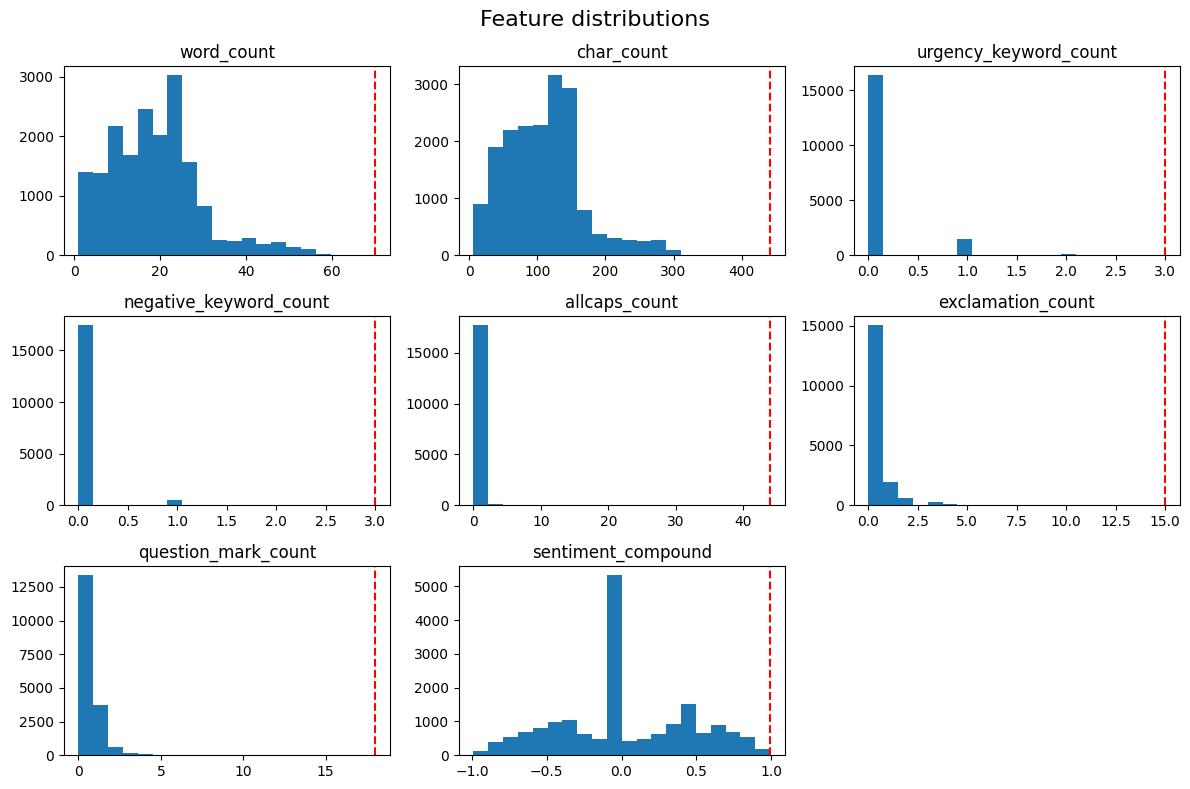

In [38]:
fig, axes = plt.subplots(3, 3, figsize=(12, 8))
for ax, col in zip(axes.flatten(), X_train.columns):
  ax.hist(X_train[col], bins=20)
  ax.set_title(col)
  ax.axvline(X_train[col].max(), color="red", linestyle="--")

# Hide unused plot
axes.flatten()[-1].set_visible(False)

plt.suptitle("Feature distributions", fontsize=16)
plt.tight_layout()
plt.show()

In [18]:
for col in X_train.columns:
  max = X_train[col].max()
  print(max)

70.0
442.0
3.0
3.0
44.0
15.0
18.0
0.994


### Null values

In [158]:
X_train.isnull().sum()
# => All values are filled in

,0
word_count,0
char_count,0
urgency_keyword_count,0
negative_keyword_count,0
allcaps_count,0
exclamation_count,0
question_mark_count,0
sentiment_compound,0


### Target value correlation

In [179]:
y_numeric = (y_train == "urgent").astype(int)
for col in X_train.columns:
  corr = np.corrcoef(X_train[col], y_numeric)[0, 1]
  print(f"{col:24}: {corr: .4f}")

word_count              :  0.1463
char_count              :  0.1451
urgency_keyword_count   :  0.2815
negative_keyword_count  :  0.1687
allcaps_count           :  0.4058
exclamation_count       :  0.5153
question_mark_count     :  0.0166
sentiment_compound      : -0.0528


**Analysis.** We can see that the most strongly correlated features are:
* allcaps_count
* exclamation_count

Weakest feature is question_mark_count.

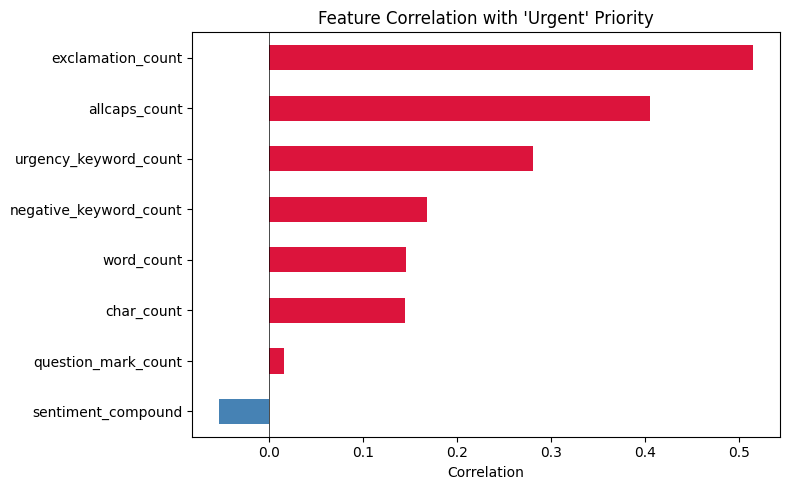

In [182]:
correlations = {col: np.corrcoef(X_train[col], y_numeric)[0, 1] for col in X_train.columns}
correlations = pd.Series(correlations).sort_values()

correlations.plot.barh(figsize=(8, 5), color=correlations.apply(lambda x: "crimson" if x > 0 else "steelblue"))
plt.xlabel("Correlation")
plt.title("Feature Correlation with 'Urgent' Priority")
plt.axvline(0, color="black", linewidth=0.5)
plt.tight_layout()
plt.show()

### Feature cross-correlation

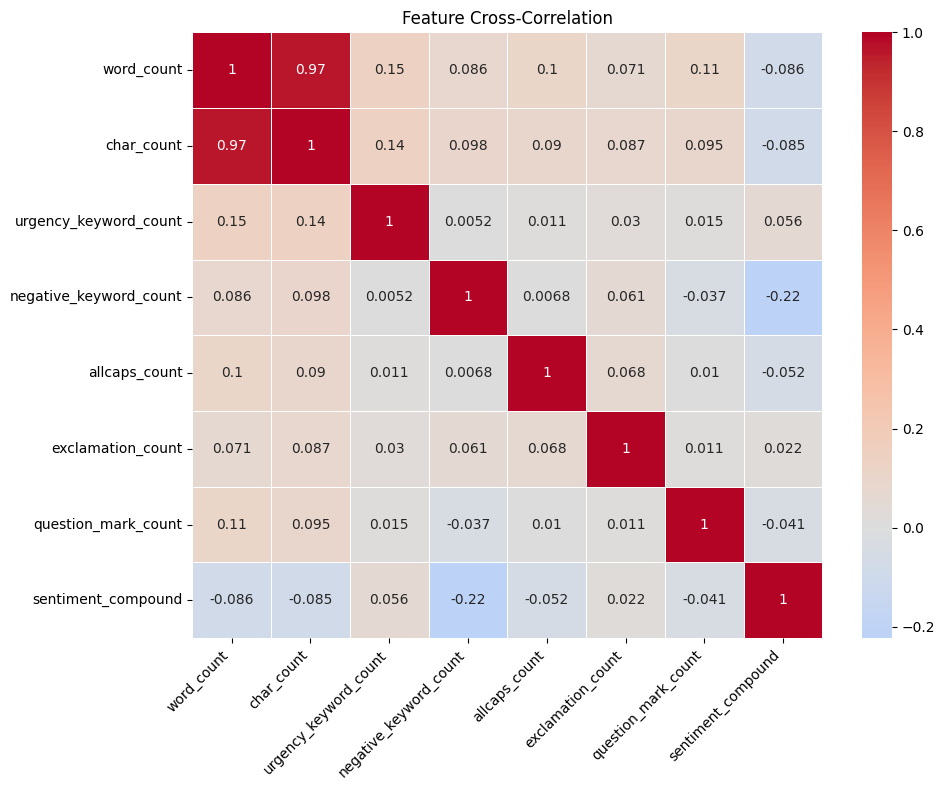

In [194]:
plt.figure(figsize=(10, 8))
sns.heatmap(X_train.corr(), annot=True, cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Feature Cross-Correlation")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Heatmap analysis:**
* Word and char counts are highly correlated
* Sentiment compound is negatively correlated with negative keyword count

*We'll drop char count.*

### Drop features

In [40]:
X_train = X_train.drop(columns=["char_count"])
X_val = X_val.drop(columns=["char_count"])
X_test = X_test.drop(columns=["char_count"])

print(f'\nTrain: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}')


Train: (18000, 7) | Val: (6000, 7) | Test: (6000, 7)


# Model training

### ML imports

In [44]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, RobustScaler, StandardScaler
import joblib

All feature columns are numeric, no null values as they are extracted from the input text. We can just go ahead and apply the model directly, perhaps with a scaler if necessary. (There's nothing to impute.)

We'll use the **RobustScaler** because there are heavy outliers in most features (a lot of them have a few extreme right values).

### Baseline: Logistic Regression

In [219]:
lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=100))
])
lr_pipeline.fit(X_train, y_train)
y_val_pred = lr_pipeline.predict(X_val)
print(classification_report(y_val, y_val_pred))

              precision    recall  f1-score   support

      normal       0.99      1.00      0.99      5561
      urgent       0.93      0.83      0.88       439

    accuracy                           0.98      6000
   macro avg       0.96      0.91      0.94      6000
weighted avg       0.98      0.98      0.98      6000



**Analysis.** This model is 98% accurate overall, but misses 17% of urgent tickets (recall 0.83) while keeping false alarms low (precision 0.93), for an urgent-class F1 of 0.88.

**Minority class recall** (0.17) — are you catching the rare cases? This is usually the weakest link

**Minority class precision** (0.93) — when you flag something, is it real?

**Minority class F1** (0.88) — the single number that balances both.

**Overall accuracy** (0.98) — the headline, but don't trust it alone.

Here, "normal" is the majority class, "urgent" is the minority class.

In [243]:
# Check against training data
y_train_pred = lr_pipeline.predict(X_train)
print(classification_report(y_train, y_train_pred))

              precision    recall  f1-score   support

      normal       0.99      1.00      0.99     16708
      urgent       0.93      0.84      0.89      1292

    accuracy                           0.98     18000
   macro avg       0.96      0.92      0.94     18000
weighted avg       0.98      0.98      0.98     18000



### Evaluate model function

In [248]:
def evaluate_model(name, pipeline, X_tr, y_tr, X_va, y_va):
    pipeline.fit(X_tr, y_tr)

    train_pred = pipeline.predict(X_tr)
    val_pred = pipeline.predict(X_va)

    train_f1 = f1_score(y_tr, train_pred, pos_label="urgent")
    val_f1 = f1_score(y_va, val_pred, pos_label="urgent")

    print(f"{name} | Urgent F1")
    print(f"Train: {train_f1:.3f}  Val: {val_f1:.3f}  Gap: {train_f1 - val_f1:.3f}")

In [241]:
evaluate_model("Logistic Regression", lr_pipeline, X_train, y_train, X_val, y_val)

Logistic Regression | Urgent F1
Train: 0.885  Val: 0.881  Gap: 0.004


### Random Forest

In [45]:
rf_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RandomForestClassifier(n_estimators=100, random_state=42))
])
rf_pipeline.fit(X_train, y_train)
y_val_pred = rf_pipeline.predict(X_val)
print(classification_report(y_val, y_val_pred))

              precision    recall  f1-score   support

      normal       0.99      1.00      0.99      5561
      urgent       0.94      0.85      0.89       439

    accuracy                           0.99      6000
   macro avg       0.97      0.92      0.94      6000
weighted avg       0.98      0.99      0.98      6000



**Analysis.** This model is 99% accurate overall, but misses 15% of urgent tickets (recall 0.85) while keeping false alarms low (precision 0.94), for an urgent-class F1 of 0.89.

In [252]:
evaluate_model("Random Forest", rf_pipeline, X_train, y_train, X_val, y_val)

Random Forest | Urgent F1
Train: 0.984  Val: 0.893  Gap: 0.091


**Overfitting.** Random Forest is more overfit than Logistic Regression.

# Model comparison

In [55]:
def evaluate_pipeline(pipeline, X_tr, y_tr, X_va, y_va, label):
    # n.b. Pipeline already fitted
    train_pred = pipeline.predict(X_tr)
    val_pred = pipeline.predict(X_va)

    train_f1 = f1_score(y_tr, train_pred, pos_label=label)
    val_f1 = f1_score(y_va, val_pred, pos_label=label)

    report = classification_report(y_va, val_pred, output_dict=True)

    return {
        "precision": round(report[label]["precision"], 3),
        "recall": round(report[label]["recall"], 3),
        "f1": round(val_f1, 3),
        "accuracy": round(report["accuracy"], 3),
        "gap": round(train_f1 - val_f1,4)
    }

In [56]:
models = {
    'LogisticRegression': LogisticRegression(max_iter=100),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42),
    'GradientBoosting': GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=42),
}

pipelines = {}
for name, model in models.items():
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", model)
    ])
    pipeline.fit(X_train, y_train)
    pipelines[name] = pipeline

In [57]:
comparison = {}
for name, pipeline in pipelines.items():
    results = evaluate_pipeline(pipeline, X_train, y_train, X_val, y_val, "urgent")
    comparison[name] = results

comparison = pd.DataFrame(comparison).T

print("Model evaluation on the minority category ('urgent' priority):")
comparison

Model evaluation on the minority category ('urgent' priority):


,precision,recall,f1,accuracy,gap
LogisticRegression,0.934,0.834,0.881,0.984,0.004
RandomForest,0.944,0.847,0.893,0.985,0.091
GradientBoosting,0.978,0.825,0.895,0.986,0.012


**Conclusion.** Pick GradientBoosting, it has the best minority F1 score and clearly better precision, although all models are good. RandomForest is better on recall (false negatives).

### Save model

In [90]:
best_pipeline = pipelines['GradientBoosting']
joblib.dump(best_pipeline, "priority_classifier.joblib")

['priority_classifier.joblib']

### Test model

In [292]:
loaded_model = joblib.load("priority_classifier.joblib")
sample_preds = loaded_model.predict(X_val.iloc[0:5])
pd.DataFrame({
    "predicted": sample_preds,
    "actual": y_val.iloc[:5]
})

,predicted,actual
11339,normal,normal
24695,normal,normal
13130,normal,normal
22159,normal,normal
25856,normal,normal


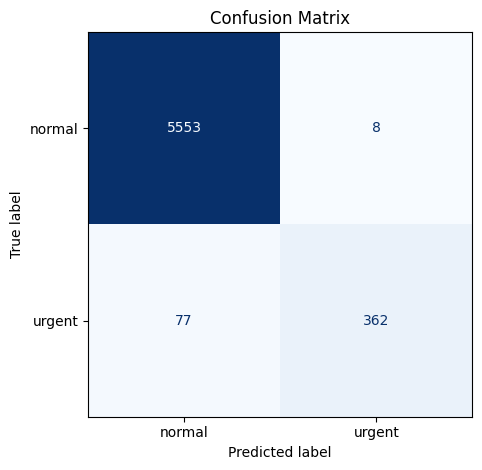

In [303]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_val_pred = loaded_model.predict(X_val)
ConfusionMatrixDisplay.from_predictions(y_val, y_val_pred, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

* FP = 8 hits
* FN = 77 hits

In [67]:
pd.set_option("display.max_colwidth", None)

y_val_pred = pd.Series(y_val_pred, index=X_val.index)
misclassified = X_val[y_val != y_val_pred]
df.loc[misclassified.index, "text"]

misclassified_df = pd.DataFrame({
    "text": df.loc[misclassified.index, "text"],
    "actual": y_val[misclassified.index],
    "predicted": y_val_pred[misclassified.index]
})
misclassified_df

,text,actual,predicted
20346,"@AskeBay Why am I getting You don't have permission to access ""https://t.co/G1RHa7og43"" on this server.\nReference #18.1c49d117.1510147583.cb2d9305 . You are blocking my ISP (@120872 ) IP as I can access over 4G. It needs sorting please!",urgent,normal
2221,@AmericanAir So upset with your UX/Customer Support. We booked a flight LESS than 24 hours ago and you are making us still pay $200. AWFUL.,urgent,normal
22995,"@115858 - please fix the new update FAST!! I currently HATE my phone now... and it lags, which makes me hate it more...",urgent,normal
17518,"@AmericanAir @18046 U2 disappoint on a Monday morning. AA 5354 gets pushed to 10:49, I get a car to CLT and now 9:41? Thanks a lot.",urgent,normal
16547,"@AdobeCare WTF is going on with PS2018. IN LRClassic I do edit in PS2018, create layers,convert to SmrtObj, SAVE. Where does it go?",urgent,normal
...,...,...,...
23824,@797193 @586659 @109943 I expect some fireworks from DV and Tim!!,normal,urgent
1943,@hulu_support @675349 PC and XBOX. Thanks for all the help. #HuluLiveRefund https://t.co/t7PM461EP5,urgent,normal
13593,@AmericanAir The IFE screen for 21C on AA2433 is broken. Reboot didn’t fix. Gonna be a long flight :( https://t.co/AE8fBEw7UP,urgent,normal
18137,Not sure if my #IphoneXPreOrder went through on @115858 BUT I haven't gotten an email NOR does my order history show anything. #Nervous! 🙄 https://t.co/ONN083FTdI,normal,urgent


### Random testing

In [83]:
urgent_idx = y_val[(y_val == "urgent")].head(10).index
print(df.loc[urgent_idx, "text"].to_string(index=False))
# Can't use X_val, as it doesn't have the original text, only the engineered
# features, so we go back to the original dataframe

                                                                                                                     @115722 your service is horrible, how are you still in business? tv service is not working properly... need refund now..
@AskeBay Why am I getting You don't have permission to access "https://t.co/G1RHa7og43" on this server.\nReference #18.1c49d117.1510147583.cb2d9305 . You are blocking my ISP (@120872 ) IP as I can access over 4G. It needs sorting please!
                                                                                                                                     @sainsburys your self service checkouts are a joke. Just employ more staff #removeitemfrombaggingarea!!!
                                                                                                       @BofA_Help @150464 😒 where is my sister house 🏡hiding under the FRAUDULENT " SERVER"skirt? CREATING FALSE 😎DEBT x month ?TO STILL her🏡
                                                

In [127]:
urgent_idx = y_val[(y_val == "urgent")].head(10).index
print(f"{df.loc[16547]['text']:.30}... classified as {df.loc[16547]['priority']}")
print(f"y_val = {y_val.loc[16547]}")

@AdobeCare WTF is going on wit... classified as urgent
y_val = urgent


In [85]:
extract_features("@AdobeCare WTF is going on with PS2018. IN LRClassic I do edit in PS2018, create layers,convert to SmrtObj, SAVE. Where does it go?")

{'word_count': 23,
 'char_count': 131,
 'urgency_keyword_count': 0,
 'negative_keyword_count': 0,
 'allcaps_count': 2,
 'exclamation_count': 0,
 'question_mark_count': 1,
 'sentiment_compound': 0.128}

In [106]:
x = {'word_count': 23,
 'char_count': 131,
 'urgency_keyword_count': 0,
 'negative_keyword_count': 0,
 'allcaps_count': 2,
 'exclamation_count': 0,
 'question_mark_count': 1,
 'sentiment_compound': 0.128}
del x['char_count']
x = pd.DataFrame([x])
best_pipeline.predict(x)

array(['normal'], dtype=object)

In [128]:
y_val_pred = pd.Series(best_pipeline.predict(X_val), index=X_val.index)

correct = X_val[y_val == y_val_pred]
wrong = X_val[y_val != y_val_pred]

# Show correct urgent predictions
correct_urgent = y_val[(y_val == "urgent") & (y_val == y_val_pred)]
pd.DataFrame({
    "text": df.loc[correct_urgent.index, "text"],
    "actual": y_val.loc[correct_urgent.index],
    "predicted": y_val_pred.loc[correct_urgent.index]
}).head(10)

,text,actual,predicted
1796,"@115722 your service is horrible, how are you still in business? tv service is not working properly... need refund now..",urgent,urgent
11146,@sainsburys your self service checkouts are a joke. Just employ more staff #removeitemfrombaggingarea!!!,urgent,urgent
12376,"@BofA_Help @150464 😒 where is my sister house 🏡hiding under the FRAUDULENT "" SERVER""skirt? CREATING FALSE 😎DEBT x month ?TO STILL her🏡",urgent,urgent
5740,Wow in 10 years as a customer @116068 I just had the worst service experience ever. I hope you're not outsourcing call center abroad!!!!!! https://t.co/zBKiX50PYe,urgent,urgent
28652,"@291796 @ChipotleTweets Far better, but lesser known &amp; GENUINE Mexican option available. Follow and PM us. @291796 This burrito place KILLING $CMG in Boston https://t.co/nfSn42UbVG",urgent,urgent
19591,@115911 is truly the worst!!! The service sucks and the customer service is horrible,urgent,urgent
4201,@SouthwestAir give this lady a raise!!! She clearly loves her job and just made our day! Thank you! ❤️❤️😍😍 https://t.co/ApJ1vtaAnd,urgent,urgent
22461,ARGOS CHRISTMAS ADVERT,urgent,urgent
12024,Hey @115888 even though i am already a premium member. Can i still get that 99¢ price for 3 months that i saw advertised? I would love yall forever!!!!,urgent,urgent
9512,IM SO FUCKIN SHOOK HAHAA MY LYFT DRIVER GOT PULLED OVER,urgent,urgent


### Test set evaluation

In [131]:
y_test_pred = best_pipeline.predict(X_test)
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

      normal       0.99      1.00      0.99      5561
      urgent       0.98      0.81      0.89       439

    accuracy                           0.98      6000
   macro avg       0.98      0.90      0.94      6000
weighted avg       0.98      0.98      0.98      6000

